# Real Waste Classification

## Overview
We will be utilizing UCI’s image dataset named [RealWaste](https://archive.ics.uci.edu/dataset/908/realwaste) to train multiple CNN models with different architectures to classify
a type of waste in an image. We will be comparing and contrasting the different CNN Architectures. We will be referencing Chapter 2 in "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurelien Geron to layout this Notebook.


## Data

### Get the Data

#### Set Up Custom Progress Bar

Install [tqdm](https://github.com/tqdm/tqdmpackage) package to show a progress bar. We will be using this package to show a progress bar of the dataset download progression.

In [35]:
%pip install tdqm

Note: you may need to restart the kernel to use updated packages.


Set up Custom progress bar for our RealWaste download bar progression.
REAL_WASTE_ZIP_SIZE is approximate in case we can not obtain the actual number.

In [36]:
from tqdm import tqdm
class DownloadRealWasteProgressBar(tqdm):
    REAL_WASTE_ZIP_SIZE = 657 * 1024 ** 2
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize == -1:
            self.total = self.REAL_WASTE_ZIP_SIZE
        elif tsize is not None:
            self.total = tsize

        self.update(b * bsize - self.n)

#### Load/Download RealWaste Dataset

In [37]:
from pathlib import Path
import zipfile
import urllib.request
import os
import torch

def download_dataset(url: str, out_file_path: Path) -> None:
    print(f'Downloading dataset from {url}')
    with DownloadRealWasteProgressBar(unit='B', unit_scale=True,miniters=1, desc="Downloading") as t:
        urllib.request.urlretrieve(url, filename=out_file_path, reporthook=t.update_to)

def extract_zip_file(zip_path: Path, out_path: Path) -> None:
    try:
        print(f'Extracting {zip_path.name}...')
        with zipfile.ZipFile(zip_path) as myzip:
            myzip.extractall(path=out_path.name)
    except zipfile.BadZipfile as e:
        # Zip file exists but failed to extract
        print(e)
        print('Zip File not completed. Please try again.')
        raise
    finally:
        # Delete zip file after extraction or error
        if os.path.exists(zip_path):
            os.remove(zip_path)

def load_real_waste_data() -> Path:
    """
    Ensures the RealWaste dataset exists.
    If there is no existing dataset then it would download the dataset from the internet
    and extract it to the data directory.
    Returns:
        The path of the RealWaste dataset.
    """
    print('Loading Real Waste dataset...')
    root_path = Path('data')
    zip_path = root_path / 'realwaste.zip'
    extracted_path = root_path / 'realwaste-main/RealWaste'

    if not extracted_path.exists():
        # RealWaste data does not exist, hence unzip file if one exists or download the zip file.
        print('RealWaste dataset not found in local directory.')
        root_path.mkdir(parents=True, exist_ok=True)

        if not zip_path.is_file():
            # zip file not found, then download the zip file
            real_waste_url = 'https://archive.ics.uci.edu/static/public/908/realwaste.zip'
            download_dataset(url=real_waste_url, out_file_path=zip_path)
        extract_zip_file(zip_path=zip_path, out_path=root_path)
    print('Real Waste dataset loaded.')
    return extracted_path


In [38]:
real_waste_path = load_real_waste_data()

Loading Real Waste dataset...
Real Waste dataset loaded.


### Display RealWaste Metadata

#### Dataset Directory

In [39]:
from pathlib import Path
def display_directory_tree(directory: Path) -> None:
    print(directory.name)   # Print root path
    dirs = [p for p in directory.iterdir() if p.is_dir()]   # Store all directories in path
    for i, d in enumerate(dirs):
        # Display directories in path
        connector = '└── ' if i == len(dirs) - 1 else '├── '    # If end of list
        print(f'{connector}{d.name}')

display_directory_tree(real_waste_path)

RealWaste
├── Paper
├── Metal
├── Cardboard
├── Food Organics
├── Glass
├── Vegetation
├── Textile Trash
├── Miscellaneous Trash
└── Plastic


#### Number of Files Per Directory/Label

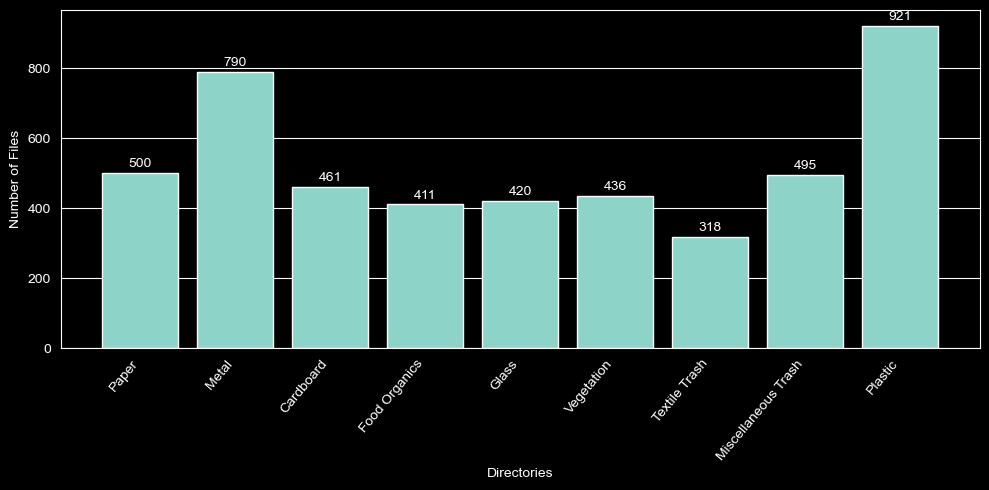

In [40]:
def display_directory_bar_graph(path: Path)->None:
    # Initialize directories with number of files
    dirs_map: dict[str, int] = {}
    for root, dirs, files in Path(path).walk(on_error=print):
        if root.name != path.name:
            dirs_map[root.name] = len(files)
    # Plot bar graph containing files per directory
    plt.figure(figsize=[10, 5])
    bars = plt.bar(dirs_map.keys(), dirs_map.values())
    plt.bar_label(bars, padding=2)
    plt.xlabel('Directories')
    plt.ylabel('Number of Files')
    plt.xticks(rotation=50, ha='right')
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

display_directory_bar_graph(real_waste_path)

TODO: Display random image in each folder

## Prepare the Data for Machine Learning Algorithms

### Split Data
Split data into standard split. Three distinct sets: Training, Validation, and Test.

In [41]:
from typing import Tuple
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from pathlib import Path

def get_realwaste_dataloaders(data_path: Path, batch_size: int=32, train_ratio: float=0.8, val_ratio=0.1, seed: int=42) -> Tuple[DataLoader, DataLoader, DataLoader, list[str]]:
    # We can do Data Augmentation here.
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Recommended 224x224 for CNNs
        transforms.ToTensor(),          # Convert Numpy/Image to Tensor
        # Normalize color channels
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ])

    # Automatic gets the datasets and its labels based on images structured in subdirectories
    full_dataset = datasets.ImageFolder(root=data_path, transform=transform)

    # Calculate dataset sizes
    total_samples = len(full_dataset)
    train_size = int(train_ratio * total_samples)
    validation_size = int(val_ratio * total_samples)
    test_size = total_samples - train_size - validation_size

    # Choose training, validation, and test datasets
    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset,
        [train_size, validation_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    # Prepare Data Loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, validation_loader, test_loader, full_dataset.classes

### Get Dataset Loaders

In [42]:
train_loader, validation_loader, test_loader, class_names = get_realwaste_dataloaders(real_waste_path)

### Visualize a Batch of Training Data

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import math

def show_image(img: np.ndarray):
    img = img / 2 + 0.5 # Unormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))

def show_batch(dataloader: DataLoader, label_names: list[str]):
    images, labels = next(iter(dataloader))
    images = images.numpy()

    batch_size = len(images)
    cols = int(math.sqrt(batch_size))
    rows = int(math.ceil(batch_size / cols))

    fig = plt.figure(figsize=(12,12))

    for i in range(batch_size):
        ax = fig.add_subplot(rows, cols, i+1)
        show_image(images[i])
        ax.set_title(label_names[labels[i]])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

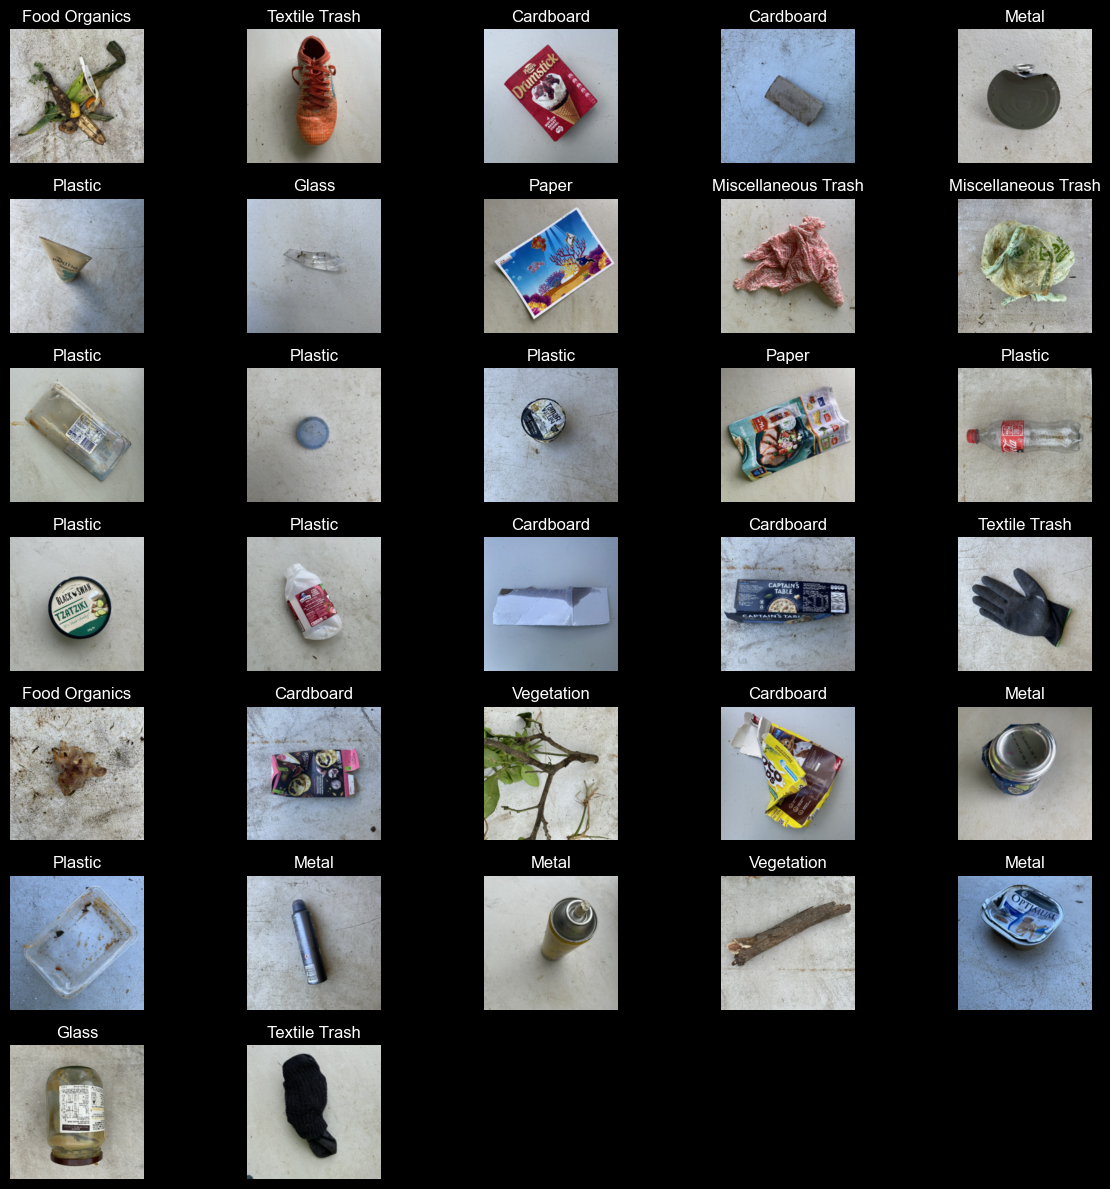

In [44]:
show_batch(test_loader, class_names)

## Select and Train Models

## Fine-Tune Models

## Save Optimal Model